# SVM : classifcation  

Support Vector Machine (SVM) is a powerful supervised machine learning algorithm used for classification and regression tasks by finding the optimal hyperplane that maximizes the margin between data classes. It is effective for linear and non-linear data using the "kernel trick" to map data into higher-dimensional spaces

The key idea behind the SVM algorithm is to find the hyperplane that best separates two classes by maximizing the margin between them. This margin is the distance from the hyperplane to the nearest data points (support vectors) on each side.

Hard margin : The algo aims to find a hyperplane that perfectly separates the data into two classes without any misclassifications. simple words there should not be data points inside both planes.


Soft Margin : the algo allows for some misclassifications to find a hyperplane that generalizes better to unseen data and is more robust to outliers .

Types : Linear SVM and Non Linear SVM


Simple SVM : Typically used for linear regression and classification problems

Kernal SVM : Has more flexible for non linear data because you can add more features to fit a hyperplane instead of a two dimensional space.


Kernal Functions : Linear , Polynomial , Gaussian RBF , Sigmoid 

Check different different kernal and apply which one fits best.

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

In [50]:
dataset = pd.read_csv("Placement.csv")
dataset.head()

,Student_ID,CGPA,IQ,Placement
0,1,6.8,123,1
1,2,5.9,106,0
2,3,5.3,121,0
3,4,7.4,132,1
4,5,5.8,142,0


In [51]:
dataset.isnull().sum()

Student_ID    0
CGPA          0
IQ            0
Placement     0
dtype: int64

Check distribution : linearly seperable or not 


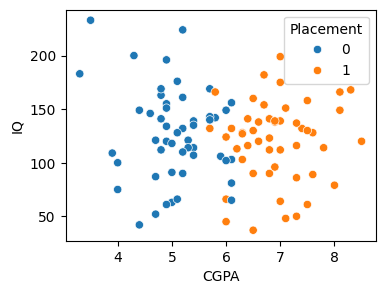

In [52]:
plt.figure(figsize=(4,3))
sns.scatterplot(x="CGPA",y="IQ",data=dataset,hue="Placement")
plt.show()

Seperate data :

In [53]:
x = dataset.iloc[:,[1,2]]
y = dataset["Placement"]

train test split :

In [54]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=52)

SVM :

SVC = Support vector classifier = for classification,
SVR = Support vector Regressor = for regression

In [55]:
from sklearn.svm import SVC

sv = SVC(kernel="linear") # using linera kernal because it is best for our current dataset 
sv.fit(x_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [56]:
print("Accuracy of test data :" ,sv.score(x_test,y_test)*100)
print("Accuracy of train data :" ,sv.score(x_train,y_train)*100)

Accuracy of test data : 90.0
Accuracy of train data : 91.25


/home/ayush-paliwal/PythonEnvironments/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


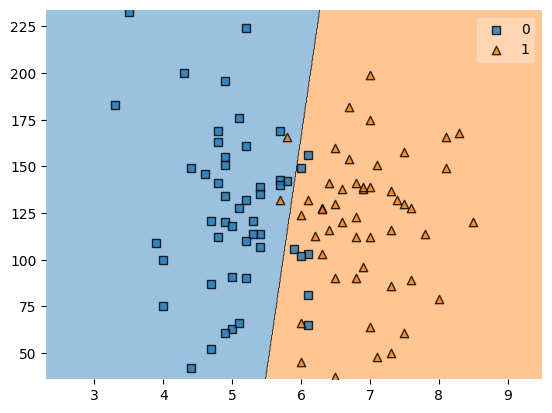

In [57]:
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=sv)
plt.show()

Using Different "Kernal" give different Curvature and gives prediction as per the kernal .

Use : hit and trail method for the best accuracy and best model training 
Use and check  different kernals for same dataset and which one gives best accuracy and good result then train model with that kernal.